In [1]:
%reload_ext autoreload
%autoreload 2

import brian2 as b2
import brian2hears as b2h
import os
from analyze.report import draw_spikes_and_psth_bothside, draw_rate_vs_angle
import matplotlib.pyplot as plt
import numpy as np
import dill

2026-01-16 13:34:04,577 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}




              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
addresses = [
'/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/sl_results/zilany/',
'/Users/francescodesantis/Documents/repos/sound_localization_model/results/',
'/g100_work/EIRI_E_POLIM2/desa/sound_localization_model/results/',
]

results_dir = addresses[1]

In [3]:
# List directory contents
items = os.listdir(results_dir)
items = sorted(items)
for item in items:
    print(item)


.DS_Store
tone_0.5kHz_90dB&Zilany&subject_0_sofa.pic
tone_0.5kHz_90dB&Zilany&subject_1_sofa.pic
tone_0.5kHz_90dB&Zilany&subject_2_sofa.pic
tone_0.5kHz_90dB&Zilany&subject_3_sofa.pic
tone_0.5kHz_90dB&Zilany&subject_4_sofa.pic


In [4]:
file_name = items[1]
result_path = results_dir + file_name

with open(result_path, "rb") as file:
    result = dill.load(file, ignore=True)

Avg firing rate (L side): 136.32 Hz POP
Avg firing rate (R side): 133.70 Hz POP
Avg firing rate (L side): 136.31 Hz
Avg firing rate (R side): 133.70 Hz


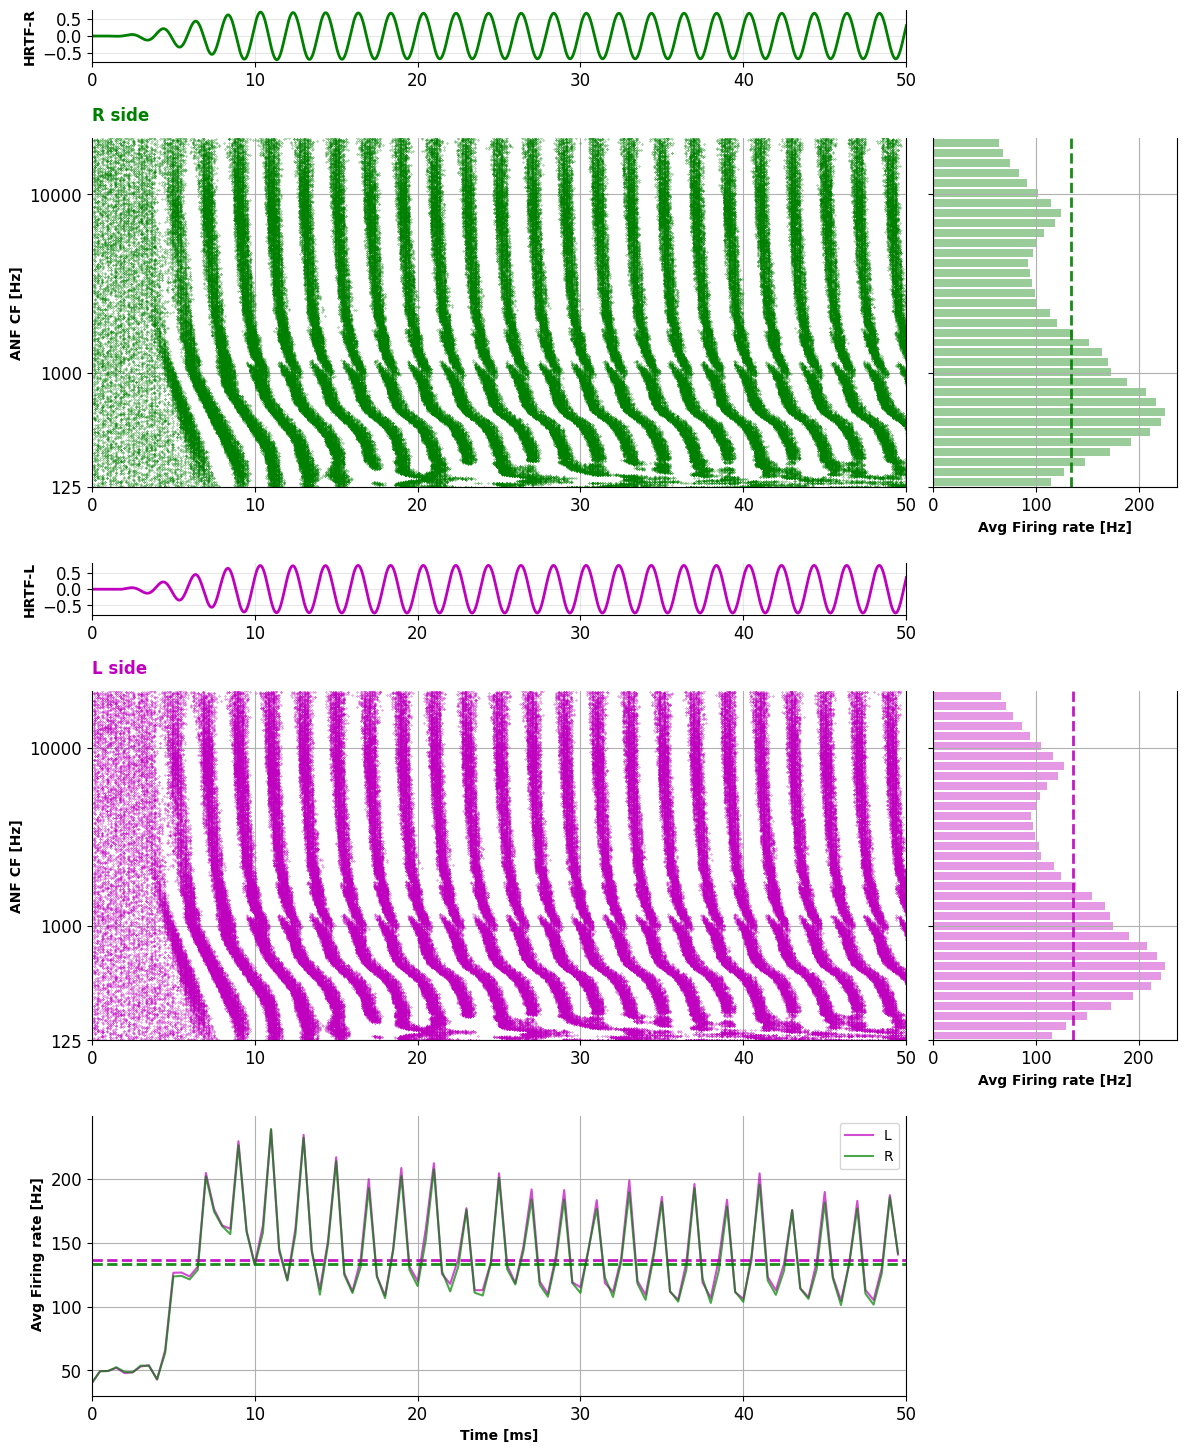

In [28]:
draw_spikes_and_psth_bothside(
    res=result,
    angle=0,
    pop='ANF',
    y_ax='cf_custom',
    xlim=(0, 50),
    bin_size=0.5,
    cf_bin_size=1000,
    hist_rate=True,
    raster_dot_size=0.5,
)

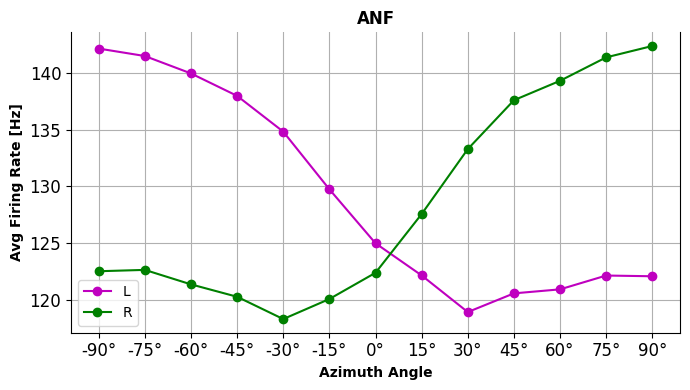

<Axes: title={'center': 'ANF'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>

In [7]:
draw_rate_vs_angle(
    data=result,
    pop='ANF', #'all'
    rate= True, #Truea, False, 'max_norm', 'mm_norm'
    show_hist = False,
    error = 'sem',
    shaded = True,
    )

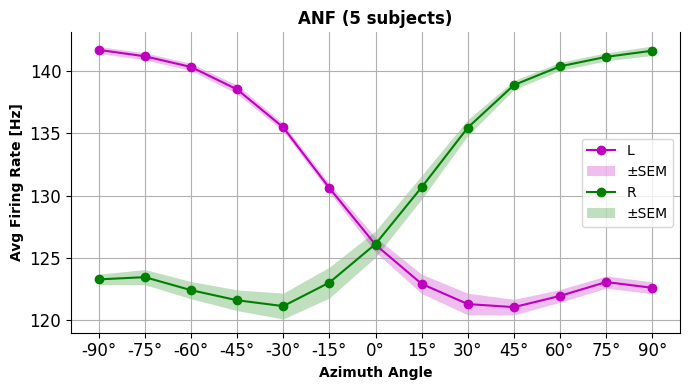

<Axes: title={'center': 'ANF (5 subjects)'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>

In [146]:
from analyze.report import draw_rate_vs_angle
import dill

dataset = []
for subject in range(5):
    file_name = f'tone_0.5kHz_90dB&Zilany&subject_{subject}_sofa.pic'
    result_path = results_dir + file_name

    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)

    dataset.append(result)
    
draw_rate_vs_angle(
    data=dataset,
    pop='ANF', #'all'
    rate= True, #Truea, False, 'max_norm', 'mm_norm'
    show_hist = False,
    error = 'sem',
    shaded = True,
    )

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Amplitude'>)

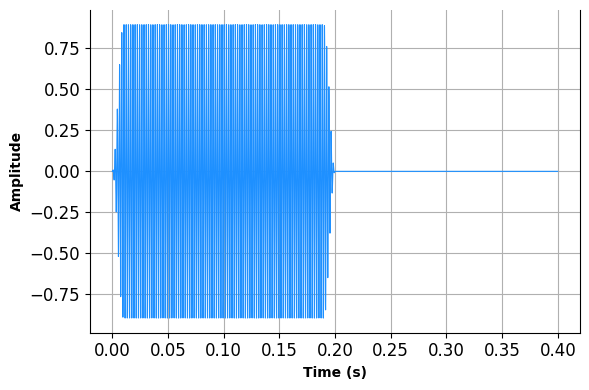

In [15]:
from utils.custom_sounds import Tone
from analyze.report import plot_sound, plot_anf_rasterplot
from utils.hrtf_utils import apply_gating
from utils.anf_utils import load_anf_response, ZI_COC_KEY
from simulate.models.BrainstemModel.params import Parameters as params

level = 90 * b2h.dB
sound = Tone(0.5 * b2.kHz, duration=200 * b2.ms, level=level, ramp_ms=10, offset_silence_duration=200 * b2.ms)
plot_sound(sound.sound, color = 'dodgerblue')


In [16]:
p = params()    
anf = load_anf_response(sound, 0, ZI_COC_KEY, p.cochlea)


2026-01-16 11:13:06,691 [INFO ]  [load_anf_response] Saved ANF not found. Regenerating...
2026-01-16 11:13:06,691 [INFO ]  [load_anf_response] Generating ANF for sound=<utils.custom_sounds.Tone object at 0x15a435af0>, angle=0, key=Zilany
2026-01-16 11:13:06,692 [INFO ]  [sound_to_spikes] Generating ANF spikes for angle=0 params={'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf', 'apply_gating': True, 'ramp_ms': 10}, 'cochlea_params': {'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}
2026-01-16 11:13:06,692 [DEBUG]  Generating spikes for sound=<utils.custom_sounds.Tone object at 0x15a435af0> angle=0 plot_spikes=False hrtf_params={'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf', 'apply_gating': True, 'ramp_ms': 10}
2026-01-16 11:13:06,692 [DEBUG]  [sound_to_spikes] Running HRTF...
2026-01-16 11:13:06,692 [DEBUG]  [run_hrtf] Starting HRTF for angle

In [17]:
anf.binaural_anf_spiketrain

{'L': 0        [0.000640000000000001, 0.007189999999999874, 0...
 1        [0.0032100000000000076, 0.015149999999999553, ...
 2        [0.013029999999999637, 0.022999999999999264, 0...
 3        [0.015589999999999533, 0.017209999999999497, 0...
 4        [0.008749999999999812, 0.013139999999999664, 0...
                                ...                        
 34995    [0.0007300000000000013, 0.021309999999999298, ...
 34996    [0.004259999999999995, 0.09468999999999601, 0....
 34997    [0.09239999999999687, 0.2228800000000824, 0.39...
 34998                                                   []
 34999                                                   []
 Name: spikes, Length: 35000, dtype: object,
 'R': 0        [0.000640000000000001, 0.007189999999999874, 0...
 1        [0.0032100000000000076, 0.01519999999999955, 0...
 2        [0.013059999999999636, 0.022969999999999265, 0...
 3        [0.01566999999999953, 0.017289999999999497, 0....
 4        [0.008749999999999812, 0.0131699999

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'ANF Raster Plot'}, xlabel='Time (s)', ylabel='Neuron index'>)

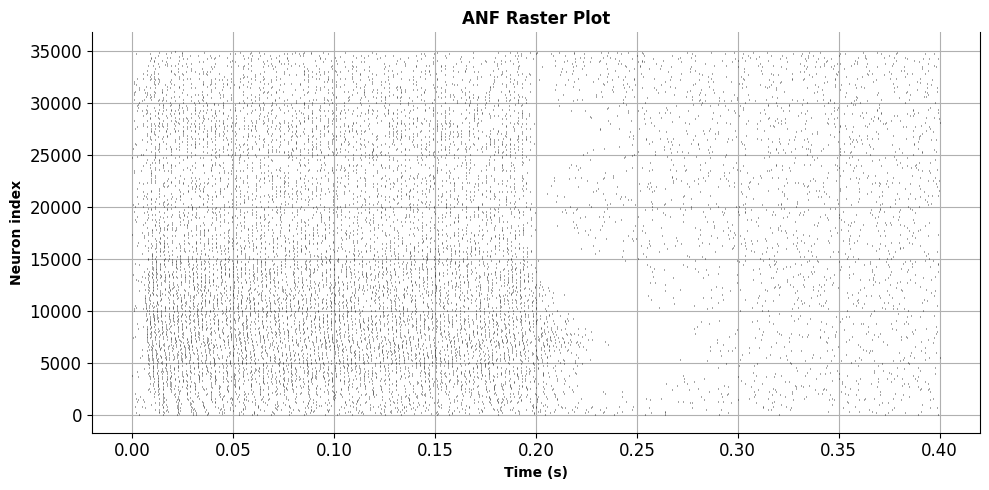

In [18]:
plot_anf_rasterplot(anf.binaural_anf_spiketrain['L'])